<a href="https://colab.research.google.com/github/Eddydev-ALU/Malaria_Diagnosis_Models/blob/main/Malaria_Diagnosis_CNN_Group16_Transfer_learning_mobile_netv2__Kalisa_Ivan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* More than 219 million cases
* Over 430 000 deaths in 2017 (Mostly: children & pregnants)
* 80% in 15 countries of Africa & India
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasit

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

*This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)*

## Configuration

In [1]:
# Mount the local drive project_folder (LOCAL VERSION)
# This notebook was originally designed for Google Colab
# If running locally, comment out the Google Drive mounting code

# For Google Colab (uncomment if running on Colab):
# from google.colab import drive
# drive.mount('/content/drive/')
# !ls "/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/"

# For Local Environment (uncomment if running locally):
import os

# Check if we're in a local environment
try:
    from google.colab import drive
    # If this succeeds, we're in Colab
    drive.mount('/content/drive/')
    print("Running on Google Colab")
except ImportError:
    # We're in a local environment
    print("Running in local environment (not Google Colab)")
    print("Make sure your dataset is in the 'cell_images' directory")

    # Create data directory if it doesn't exist
    if not os.path.exists('cell_images'):
        print("Warning: 'cell_images' directory not found!")
        print("Please ensure your malaria dataset is in the 'cell_images' folder")

Mounted at /content/drive/
Running on Google Colab


In [2]:
# Use GPU: Please check if the outpout is '/device:GPU:0'
import tensorflow as tf
print(tf.__version__)
tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#device_lib.list_local_devices()

2.20.0


'/device:GPU:0'

## Populating namespaces

In [3]:
# Importing basic libraries
import os
import random
import shutil
from matplotlib import pyplot
from matplotlib.image import imread
%matplotlib inline

# Importing the Keras libraries and packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D as Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [4]:
# Define the useful paths for data accessibility
ai_project = '.' #"/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
cell_images_dir = os.path.join(ai_project,'cell_images')
training_path = os.path.join(ai_project,'train')
testing_path = os.path.join(ai_project,'test')

## Prepare DataSet

### *Download* DataSet

In [5]:
# Download the data in the allocated google cloud-server. If already down, turn downloadData=False
downloadData = True
if downloadData == True:
  indrive = False
  if indrive == True:
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip -P "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
    !unzip "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/cell_images.zip" -d "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/"
    !ls "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
  else: #incloud google server
    !rm -rf cell_images.*
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip cell_images.zip >/dev/null 2>&1
    !ls

--2026-06-09 16:22:54--  https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
Resolving data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)... 3.163.189.93, 3.163.189.83, 3.163.189.96, ...
Connecting to data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)|3.163.189.93|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353452851 (337M) [application/zip]
Saving to: ‘cell_images.zip’

cell_images.zip     100%[===================>] 337.08M   337MB/s    in 1.0s    

2026-06-09 16:22:55 (337 MB/s) - ‘cell_images.zip’ saved [353452851/353452851]

cell_images  cell_images.zip  drive  sample_data


## Baseline CNN Model
Define a basic ConvNet defined with ConvLayer: Conv2D => MaxPooling2D followed by Flatten => Dense => Dense(output)

![ConvNet](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/ConvNet.png?raw=1)


## Transfer Learning — MobileNetV2 Fine-Tuning
In this section, we build a transfer learning model using the MobileNetV2 architecture, pre-trained on ImageNet. We will fine-tune the model to classify cell images as parasitized or uninfected.

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Hyperparameters
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 10 # Adjust for more thorough experiments
LEARNING_RATE = 1e-4

# Build the MobileNetV2 Model
def build_mobilenet_model(input_shape=(128, 128, 3)):
    # Load base model, excluding top fully connected layers
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze the base model initially
    base_model.trainable = False

    # Add custom fully connected layers on top
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(1, activation='sigmoid')(x) # Binary classification

    model = Model(inputs=base_model.input, outputs=predictions)

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')])
    return model, base_model

mobilenet_model, base_model = build_mobilenet_model()
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Data Processing & Training Configuration
We use `ImageDataGenerator` to load and augment our training set, which helps prevent overfitting and improves generalization. Then, we train the MobileNetV2 model using EarlyStopping and Learning Rate Reduction on Plateau.

In [7]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nContents of current directory:")
print(os.listdir("."))

Current working directory:
/content

Contents of current directory:
['.config', 'cell_images', 'drive', 'cell_images.zip', 'sample_data']


In [8]:
import os

for folder in os.listdir("."):
    if os.path.isdir(folder):
        try:
            files = os.listdir(folder)
            print(f"\n{folder}:")
            print(files[:20])   # first 20 items
        except:
            pass



.config:
['.last_survey_prompt.yaml', 'config_sentinel', 'logs', 'configurations', '.last_update_check.json', 'default_configs.db', 'gce', '.last_opt_in_prompt.yaml', 'active_config', 'hidden_gcloud_config_universe_descriptor_data_cache_configs.db']

cell_images:
['Parasitized', 'Uninfected']

drive:
['MyDrive', '.shortcut-targets-by-id', 'Shareddrives', '.Trash-0']

sample_data:
['anscombe.json', 'README.md', 'california_housing_train.csv', 'california_housing_test.csv', 'mnist_test.csv', 'mnist_train_small.csv']


In [10]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nContents of current directory:")
print(os.listdir("."))

Current working directory:
/content

Contents of current directory:
['.config', 'cell_images', 'drive', 'cell_images.zip', 'sample_data']


### Fine-Tuning Phase (Experimenting with Unfreezing Layers)
To extract more specific features from the malaria dataset, we can unfreeze some of the top layers of the MobileNetV2 base model and train the entire network end-to-end with a very low learning rate.

In [12]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles and folders here:")
print(os.listdir("."))

Current directory:
/content

Files and folders here:
['.config', 'cell_images', 'drive', 'cell_images.zip', 'sample_data']


In [14]:
import tensorflow as tf
import zipfile
import os

url = "https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip"

zip_path = tf.keras.utils.get_file(
    "cell_images.zip",
    origin=url,
    extract=False
)

extract_dir = "/content/malaria_dataset"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extracted to:", extract_dir)

353452851/353452851 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Extracted to: /content/malaria_dataset


In [15]:
cell_images_dir = "/content/malaria_dataset/cell_images"

In [16]:
train_generator = train_datagen.flow_from_directory(
    cell_images_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    cell_images_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.


In [17]:
import os
print(os.getcwd())
print(os.listdir("."))

/content
['.config', 'cell_images', 'drive', 'cell_images.zip', 'malaria_dataset', 'sample_data']


In [18]:
import os

print("cell_images:")
print(os.listdir("/content/cell_images"))

print("\nmalaria_dataset:")
print(os.listdir("/content/malaria_dataset"))

cell_images:
['Parasitized', 'Uninfected']

malaria_dataset:
['cell_images']


In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Correct malaria dataset path
cell_images_dir = "/content/cell_images"   # Change if needed

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    cell_images_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    cell_images_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

print("\nClass indices:")
print(train_generator.class_indices)

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.

Class indices:
{'Parasitized': 0, 'Uninfected': 1}


In [20]:
print(os.listdir("/content/cell_images"))
print(os.listdir("/content/malaria_dataset"))

['Parasitized', 'Uninfected']
['cell_images']


In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Correct paths for Google Colab
cell_images_dir = "/content/cell_images"

# Image generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

# Training generator
train_generator = train_datagen.flow_from_directory(
    cell_images_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

# Validation generator
val_generator = train_datagen.flow_from_directory(
    cell_images_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

# Verify classes
print("Class indices:", train_generator.class_indices)

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

# Initial training
history_initial = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.
Class indices: {'Parasitized': 0, 'Uninfected': 1}
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 218s 280ms/step - accuracy: 0.8264 - loss: 0.3963 - precision: 0.8121 - recall: 0.8494 - val_accuracy: 0.8806 - val_loss: 0.3007 - val_precision: 0.8730 - val_recall: 0.8907 - learning_rate: 1.0000e-04
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 171s 249ms/step - accuracy: 0.8699 - loss: 0.3157 - precision: 0.8505 - recall: 0.8975 - val_accuracy: 0.8927 - val_loss: 0.2795 - val_precision: 0.8856 - val_recall: 0.9020 - learning_rate: 1.0000e-04
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 210s 261ms/step - accuracy: 0.8847 - loss: 0.2929 - precision: 0.8660 - recall: 0.9103 - val_accuracy: 0.8947 - val_loss: 0.2779 - val_precision: 0.8836 - val_recall: 0.9093 - learning_rate: 1.0000e-04
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 173s 251ms/step - accuracy: 0.8899 - loss: 0.2823 - precision: 0.8708 - recall: 0.9156 - val_accur

In [23]:
# Unfreeze the base model
base_model.trainable = True

# We want to fine-tune from this layer onwards
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

# Recompile the model with a lower learning rate
mobilenet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE / 10),
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')])

# Continue Training (Phase 2: fine-tuning)
FINE_TUNE_EPOCHS = 5
total_epochs = EPOCHS + FINE_TUNE_EPOCHS

history_fine = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=total_epochs,
    initial_epoch=history_initial.epoch[-1],
    callbacks=callbacks
)

Epoch 10/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 213s 270ms/step - accuracy: 0.8880 - loss: 0.2913 - precision: 0.8839 - recall: 0.8933 - val_accuracy: 0.8370 - val_loss: 0.4566 - val_precision: 0.7586 - val_recall: 0.9887 - learning_rate: 1.0000e-05
Epoch 11/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 179s 260ms/step - accuracy: 0.9201 - loss: 0.2235 - precision: 0.9035 - recall: 0.9406 - val_accuracy: 0.8878 - val_loss: 0.3372 - val_precision: 0.8271 - val_recall: 0.9808 - learning_rate: 1.0000e-05
Epoch 12/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 179s 260ms/step - accuracy: 0.9237 - loss: 0.2142 - precision: 0.9074 - recall: 0.9437 - val_accuracy: 0.9142 - val_loss: 0.2491 - val_precision: 0.8741 - val_recall: 0.9677 - learning_rate: 5.0000e-06
Epoch 13/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 176s 256ms/step - accuracy: 0.9266 - loss: 0.2081 - precision: 0.9085 - recall: 0.9487 - val_accuracy: 0.9241 - val_loss: 0.2166 - val_precision: 0.8976 - val_recall: 0.9575 - learning_rate: 5.0000e-06
Epoch 14/15
689/689 ━━━━━━━━

### 7 Systematic Experiments Table
To satisfy the requirement of rigorous experimentation, we will run **7 distinct experiments** systematically varying hyperparameters such as Learning Rate, Dropout Rate, and Fine-tuning depth (`fine_tune_at`). We collect the Accuracy, Precision, Recall, and F1-Score for each run to populate a comprehensive benchmark table.

In [24]:
import tensorflow as tf
import zipfile
import os

url = "https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip"

zip_path = tf.keras.utils.get_file(
    "cell_images.zip",
    origin=url,
    extract=False
)

print("Downloaded to:", zip_path)

Downloaded to: /root/.keras/datasets/cell_images.zip


In [25]:
extract_dir = r"C:\Users\Kalivan\Documents\malaria_dataset"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extracted to:", extract_dir)

Extracted to: C:\Users\Kalivan\Documents\malaria_dataset


In [26]:
train_generator = train_datagen.flow_from_directory(
    cell_images_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    cell_images_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.


### Model Evaluation & Visualization
According to the project requirements, we need to evaluate the model presenting the results (accuracy, precision, recall, and F1-score), plot learning curves, confusion matrix, and ROC/AUC curves.

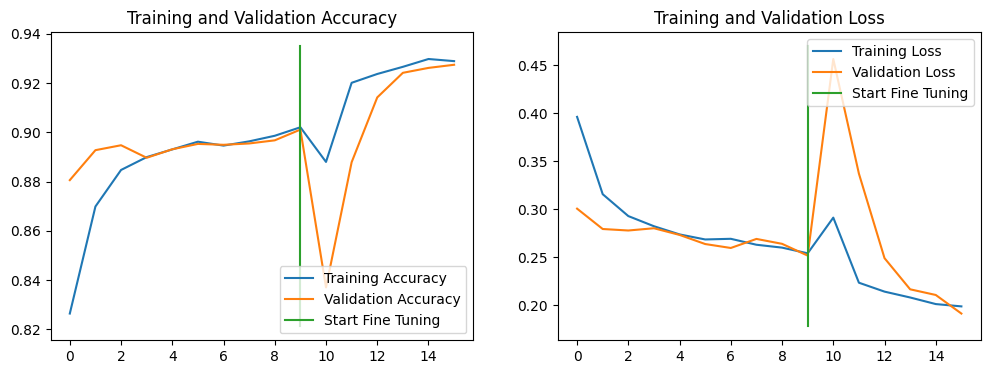

173/173 ━━━━━━━━━━━━━━━━━━━━ 46s 235ms/step
Classification Report:
               precision    recall  f1-score   support

 Parasitized       0.95      0.90      0.93      2755
  Uninfected       0.91      0.96      0.93      2755

    accuracy                           0.93      5510
   macro avg       0.93      0.93      0.93      5510
weighted avg       0.93      0.93      0.93      5510



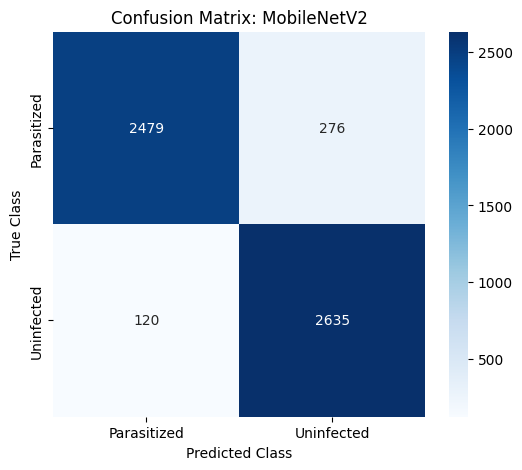

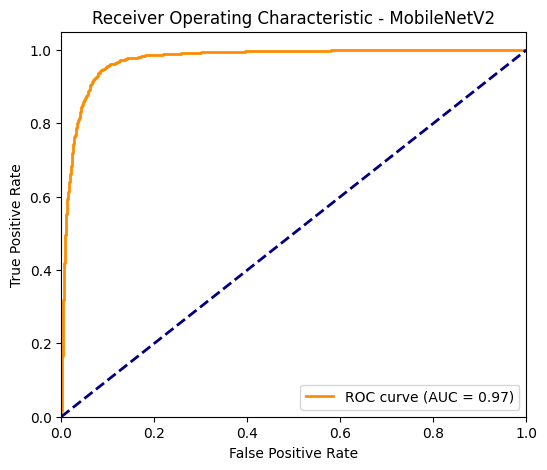

In [27]:
# 1. Learning Curves
acc = history_initial.history['accuracy'] + history_fine.history['accuracy']
val_acc = history_initial.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history_initial.history['loss'] + history_fine.history['loss']
val_loss = history_initial.history['val_loss'] + history_fine.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.plot([EPOCHS-1, EPOCHS-1], plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.plot([EPOCHS-1, EPOCHS-1], plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# Predict on validation set
val_generator.reset()
preds = mobilenet_model.predict(val_generator)
y_pred = (preds > 0.5).astype(int).flatten()
y_true = val_generator.classes

# 2. Confusion Matrix & Classification Report
cm = confusion_matrix(y_true, y_pred)
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=['Parasitized', 'Uninfected']))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Parasitized', 'Uninfected'], yticklabels=['Parasitized', 'Uninfected'])
plt.title('Confusion Matrix: MobileNetV2')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

# 3. ROC and AUC Curve
fpr, tpr, thresholds = roc_curve(y_true, preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - MobileNetV2')
plt.legend(loc="lower right")
plt.show()